# ДЗ Линейная регрессия

В данном задании мы рассмотрим набор данных об учащихся, собранный в 2006 году в одной из школ Португалии. Данные представлены в неудобном для машинного обучения виде, и содержат мусор. Ваша задача &mdash; привести их к надлежащему виду и обучить на них простую модель.

Данные состоят из четырех файлов:
- data.csv &mdash; основная таблица с информацией о учащихся
- scores.csv &mdash; список финальных оценок по одному из предметов (20-балльная шкала переведенная в проценты)
- attendance.csv &mdash; таблица посещений занятий по этому предмету
- school_support.txt &mdash; список учащихся, которым оказывается финансовая поддержка

Ваша задача &mdash; построить модель для предсказания финальных оценок исходя из всех остальных данных и проверить качество ее работы с помощью кросс-валидации. В качестве алгоритма мы будем использовать линейную регрессию

Расшифровка столбцов в data.csv для справки:
- age &mdash; возраст
- Medu &mdash; уровень образования матери (по некоторой условной шкале)
- Fedu &mdash; уровень образования отца (по некоторой условной шкале)
- traveltime &mdash; время в пути до школы (1 – < 15 мин., 2 – от 15 до 30 мин., 3 – от 30 мин. to 1 ч.
или 4 – > 1 ч.)
- studytime &mdash; время, затрачиваемое на занятия вне школы (1 – < 2 ч., 2 – от 2 до 5 ч., 3 – от 5 до 10 ч. или 4 – > 10 ч.)
- famrel &mdash; насколько хорошие отношения в семье у учащегося (по некоторой условной шкале)
- freetime &mdash; количество свободного времени вне школы (по некоторой условной шкале)
- goout &mdash; время, затрачиваемое на общение с друзьями (по некоторой условной шкале)
- Dalc &mdash; количество употребления алкоголя в учебные дни (по некоторой условной шкале)
- Walc &mdash; количество употребления алкоголя в неучебные дни (по некоторой условной шкале)
- health &mdash; уровень здоровья (по некоторой условной шкале)
- sex_M &mdash; пол: мужской (1) или женский (0)
- address_U &mdash; живет ли учащийся в городе (1) или в пригороде (0)
- famsize_LE3 &mdash; размер семьи: не больше 3 человек (1) или больше (0)
- Pstatus_T &mdash; живут ли родители вместе (1) или отдельно (0)
- nursery &mdash; посещал ли учащийся детский сад
- plans_university &mdash; планирует ли учащийся поступать в университет (-1 или 1)
- past_failures &mdash; количество неудовлетворительных оценок по другим предметам ранее (от 0 до 4)

*Примечание. Несколько признаков в данных содержат ошибки/проблемы/некорректности. Эти проблемы нужно исправить. Для
проверки &mdash; всего в данных таких проблем четыре.*

Начиная с 4 пункта делайте кроссвалидацию на 4 батча до и после, замеряйте результат

### Задача 1: сломанный признак (а может и не один)
__(1 балл)__

Загрузите таблицу data.csv.

Найдите в данных сломанный признак (он не соответствует описанию) и исправьте его.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score, train_test_split

data_raw = pd.read_csv(r"C:\Users\Tim\Desktop\ML-SUNC11\taks_linreg\task\data.csv")

data = data_raw.copy()
joined = data["plans_universitypast_failures"]
data["plans_university"] = np.sign(joined)
data["past_failures"] = joined.abs() % 10
data = data.drop(columns="plans_universitypast_failures")



### Задача 2: пропуски в данных 
__(1 балл)__

Проверьте, есть ли в данных пропуски (значения NaN). Замените все пропущенные значения на среднее значение этого признака по столбцу.

*Hint: изучите в pandas функции loc, isnull, а также передачу булевых массивов в качестве индексов.*

In [2]:
data = data.fillna(data.mean())


### Задача 3: нормализация данных
__(1 балл)__

Нормализуйте данные любым способом, в современных библиотеках нормализация часто встроена внутрь модели, поэтому тут разницы может и не быть в качестве, но сделать надо

In [3]:
data_normalized = (data - data.mean()) / data.std()


### Задача 4: кросс-валидация для исходных данных
__(1 балл)__

Загрузите файл scores.csv и протестируйте, как линейная регрессия предсказывает ответ сейчас (с помощью кросс-валидации).

Кроссвалидацию сделайте по 4 разбивкам. Выведите качество в каждом их разбиений.

*Hint: воспользуйтесь sklearn.linear_model и sklearn.model_selection.*

In [4]:
scores = pd.read_csv(r"C:\Users\Tim\Desktop\ML-SUNC11\taks_linreg\task\scores.csv", header=None)[0]
folds = KFold(n_splits=4, shuffle=True, random_state=42)
model = LinearRegression()

base_r2 = cross_val_score(model, data_normalized, scores, cv=folds, scoring="r2")
base_mae = -cross_val_score(model, data_normalized, scores, cv=folds, scoring="neg_mean_absolute_error")
print("Исходные данные:")
print(pd.DataFrame({"R2": base_r2, "MAE": base_mae}).round(3))


Исходные данные:
      R2     MAE
0  0.175  11.646
1  0.312  11.352
2  0.243   9.249
3  0.081  10.680


### Задача 5: полные данные
__(2 балла)__

Воспользуйтесь файлами attendance.csv и school_support.txt для того, чтобы добавить новые признаки в данные. Желательно по максимуму использовать возможности pandas для упрощения преобразований.

school_suport число в строке значит что i-ый школьник из исходной таблицы получал мат помощь (обратите внимание что строк в файле меньше, подумайте как правильно импортировать данные)

Добавьте данные таким образом, чтобы качество выросло

In [5]:
attendance = pd.read_csv(r"C:\Users\Tim\Desktop\ML-SUNC11\taks_linreg\task\attendance.csv", sep=";")
support_ids = pd.read_csv(r"C:\Users\Tim\Desktop\ML-SUNC11\taks_linreg\task\school_support.txt", header=None)[0]

data_full = data.copy()
data_full["attended_lessons"] = attendance.notna().sum(axis=1)
data_full["school_support"] = data_full.index.isin(support_ids).astype(int)

full_r2 = cross_val_score(model, data_full, scores, cv=folds, scoring="r2")
full_mae = -cross_val_score(model, data_full, scores, cv=folds, scoring="neg_mean_absolute_error")
print("С посещаемостью и поддержкой:")
print(pd.DataFrame({"R2": full_r2, "MAE": full_mae}).round(3))


С посещаемостью и поддержкой:
      R2     MAE
0  0.197  11.445
1  0.315  11.343
2  0.252   9.142
3  0.075  10.602


### Задача 6: борьба с выбросами
__(1.5 балла)__

Качество предсказания может ухудшаться, если в данных присутствуют корректные значения признаков (с точки зрения чтения данных и применения методов), но не соответствующие реальным объектам. Например, данные могли быть введены в неверном формате, а потом слишком грубо приведены к общему виду, из-за чего ошибка не была замечена.
Попробуем от такого избавиться &mdash; а для этого такие объекты нужно сначала найти. Конечно, нам еще недоступны многие продвинутые способы, но давайте попробуем обойтись простыми.

Первый способ это сделать &mdash; посмотреть для каждого признака на распределение его значений и проверить крайние значения на правдоподобность. (постройте гистограммы для признаков, как минимум для подозрительных)

*Hint 1: используйте функцию DataFrame.hist*

*Hint 2: в описании датасета выше есть информация, необходимая для восстановления правильных значений*

Необычные значения age: [1987 1988 1989 1990 1991]
Необычные значения traveltime: [10 25 50 40]
После исправления возраста и времени в пути:
      R2     MAE
0  0.203  11.393
1  0.315  11.295
2  0.254   9.010
3  0.105  10.464


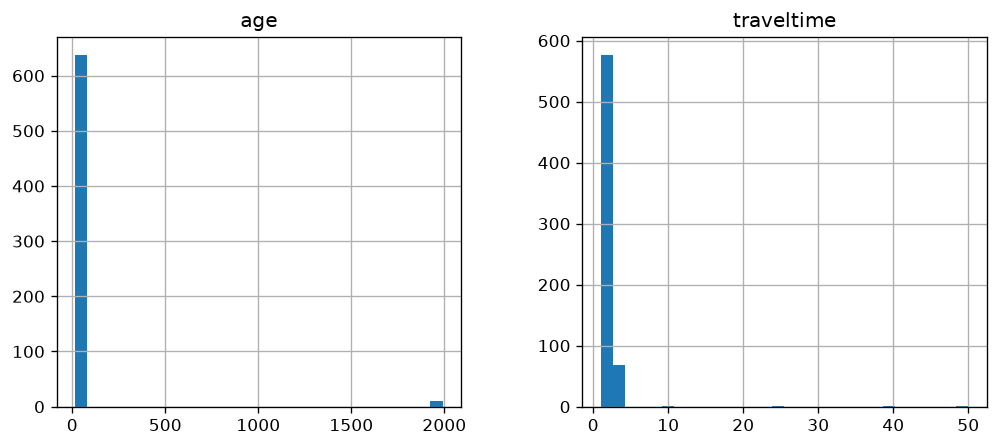

In [6]:
data_full[["age", "traveltime"]].hist(bins=30, figsize=(10, 4))
plt.show()
print("Необычные значения age:", data_full.loc[data_full["age"] > 100, "age"].unique())
print("Необычные значения traveltime:", data_full.loc[data_full["traveltime"] > 4, "traveltime"].unique())

data_repaired = data_full.copy()
data_repaired.loc[data_repaired["age"] > 100, "age"] = 2006 - data_repaired["age"]

data_repaired["traveltime"] = data_repaired["traveltime"].replace({10: 1, 25: 2, 40: 3, 50: 3})

features_repaired_r2 = cross_val_score(model, data_repaired, scores, cv=folds, scoring="r2")
features_repaired_mae = -cross_val_score(model, data_repaired, scores, cv=folds, scoring="neg_mean_absolute_error")
print("После исправления возраста и времени в пути:")
print(pd.DataFrame({"R2": features_repaired_r2, "MAE": features_repaired_mae}).round(3))


__(1.5 балла)__

Другой простой способ найти выбросы &mdash; сделать предсказание и посчитать ошибку на каждом объекте по отдельности и посмотреть на объекты с наибольшей ошибкой. Обучите линейную регрессию (функция fit) и для каждого объекта посчитайте среднеквадратичное отклонение. Постройте гистограмму распределения ошибок. Посмотрите на гистограмму и удалите из выборки те объекты на которых ошибка слишком большая.

Обратите внимание, что просто удалять все объекты с высокой ошибкой нельзя &mdash; это, конечно, хороший способ добиться меньшей ошибки (на данной выборке), но одновременно вы ухудшите обобщающую способность алгоритма. Вместо этого вам нужно найти однозначно ошибочные записи и их исправить.

*Hint: возможно, все проблемы уже были найдены первым способом; для проверки &mdash; в сумме здесь нужно исправить 3 проблемы.*

Для поиска ошибки на одном отдельном обьекте придётся обучить линейную регрессию руками. Частичный пример, допишите код. Постройте гистограмму распределения ошибок

MAE на проверочных 30%: 11.15


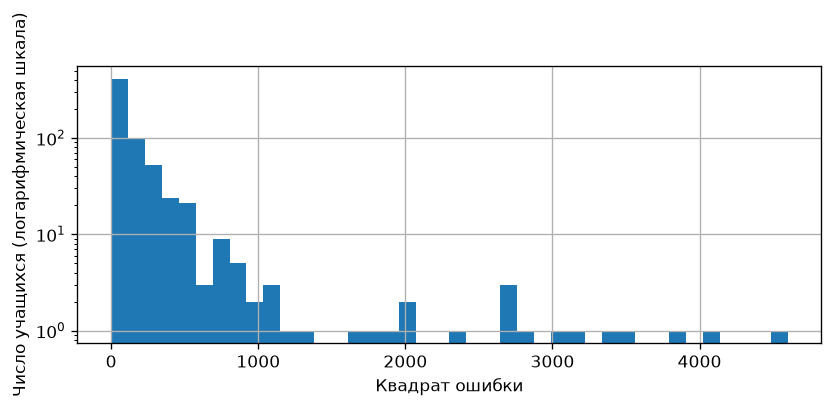

In [7]:
# Здесь способ обучения не задан, поэтому берём 70% для обучения и 30% для проверки.
x_train, x_test, y_train, y_test = train_test_split(
    data_repaired, scores, test_size=0.3, shuffle=True, random_state=42
)
model.fit(x_train, y_train)
print("MAE на проверочных 30%:", round(abs(y_test - model.predict(x_test)).mean(), 3))

# Для поиска ошибочных записей смотрим ошибки всех учащихся.
prediction = model.predict(data_repaired)
squared_error = (scores - prediction) ** 2
squared_error.hist(bins=40, figsize=(8, 3))
plt.yscale("log")
plt.xlabel("Квадрат ошибки")
plt.ylabel("Число учащихся (логарифмическая шкала)")
plt.show()


In [8]:
errors = pd.DataFrame({"score": scores, "prediction": prediction, "squared_error": squared_error})
print(errors.nlargest(20, "squared_error").round(2))

scores_repaired = scores.copy()
wrong_scores = (scores_repaired > 0) & (scores_repaired < 1)
scores_repaired.loc[wrong_scores] = (scores_repaired.loc[wrong_scores] * 100).round()
print(pd.DataFrame({"до": scores[wrong_scores], "после": scores_repaired[wrong_scores]}))


     score  prediction  squared_error
585   0.70       68.51        4597.93
354   0.00       64.27        4130.88
319   0.00       62.38        3891.55
615   0.00       59.03        3484.70
385   0.00       57.79        3340.15
257   0.55       57.12        3200.60
303   0.00       54.69        2990.91
404   0.55       53.75        2830.47
423   0.00       52.49        2755.18
231   0.50       52.67        2721.75
462   0.00       52.03        2706.92
557   0.00       48.25        2327.90
501   0.00       45.28        2050.28
492   0.00       44.90        2015.92
436   5.00       47.91        1841.06
137   0.00       41.53        1724.36
287   0.00       40.21        1616.54
366   0.00       35.80        1281.67
544  90.00       55.50        1189.96
196   0.35       33.99        1131.69
       до  после
196  0.35   35.0
231  0.50   50.0
257  0.55   55.0
404  0.55   55.0
585  0.70   70.0


### Финальное предсказание и отчёт (1 балл)

Проведите предсказание еще раз и сравните качество с исходным. Запишите свои наблюдения - как изменялось качество обучения модели при использовании разных модификаций данных. 

После всех исправлений:
      R2     MAE
0  0.263  10.288
1  0.321  10.740
2  0.263   9.110
3  0.113  10.497
               этап  средний R2  средняя MAE
           Исходные       0.203       10.732
 Добавлены признаки       0.210       10.633
Исправлены признаки       0.219       10.540
  Исправлены оценки       0.240       10.159


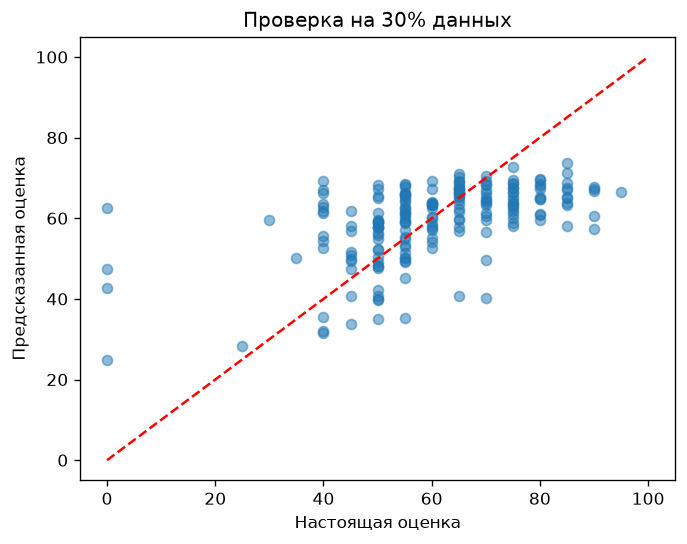

In [9]:
final_r2 = cross_val_score(model, data_repaired, scores_repaired, cv=folds, scoring="r2")
final_mae = -cross_val_score(model, data_repaired, scores_repaired, cv=folds, scoring="neg_mean_absolute_error")
print("После всех исправлений:")
print(pd.DataFrame({"R2": final_r2, "MAE": final_mae}).round(3))

summary = pd.DataFrame({
    "этап": ["Исходные", "Добавлены признаки", "Исправлены признаки", "Исправлены оценки"],
    "средний R2": [base_r2.mean(), full_r2.mean(), features_repaired_r2.mean(), final_r2.mean()],
    "средняя MAE": [base_mae.mean(), full_mae.mean(), features_repaired_mae.mean(), final_mae.mean()],
})
print(summary.round(3).to_string(index=False))

x_train, x_test, y_train, y_test = train_test_split(
    data_repaired, scores_repaired, test_size=0.3, shuffle=True, random_state=42
)
model.fit(x_train, y_train)
test_predictions = model.predict(x_test)
plt.scatter(y_test, test_predictions, alpha=0.5)
plt.plot([0, 100], [0, 100], "r--")
plt.xlabel("Настоящая оценка")
plt.ylabel("Предсказанная оценка")
plt.title("Проверка на 30% данных")
plt.show()


**Вывод.** После исправлений средний R² вырос с 0.203 до 0.240, а средняя MAE снизилась с 10.732 до 10.159 пункта. Ошибка всё ещё около 10 пунктов, поэтому модель предсказывает оценки не очень точно.